In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit

In [ ]:
                                                    # ТЕОРИЯ

In [ ]:
def tune_sigma(lattice, positions, T, N, initial_sigma=np.pi/8, target=0.5, tune_steps=1000):

    sigma = initial_sigma
    for _ in range(10):  # максимум 10 итераций
        accepted = 0
        temp_lattice = lattice.copy()
        for _ in range(tune_steps):
            _, acc = metropolis_step(temp_lattice, positions, T, N, sigma)
            if acc:
                accepted += 1
        acceptance = accepted / tune_steps

        if acceptance > target + 0.05:
            sigma *= 1.1
        elif acceptance < target - 0.05:
            sigma *= 0.9
        else:
            break
    return sigma

In [ ]:
@numba.njit
def create_lattice(N):
    return np.random.uniform(0, 2*np.pi, size=(N, N))

In [ ]:
@numba.njit
def build_triangular_positions(N, a=1.0):
    positions = []
    for i in range(N):
        for j in range(N):
            x = j + i/2
            y = i * np.sqrt(3) / 2
            # if i % 2 == 1:
            #     x += a / 2
            positions.append([x, y])
    return np.array(positions)

In [ ]:
@numba.njit
def idx_to_ij(idx, N):
    return idx // N, idx % N

In [ ]:
@numba.njit
def ij_to_idx(i, j, N):
    return i * N + j

In [ ]:
@numba.njit
def angle_to_vector(angle):
    return np.array([np.cos(angle), np.sin(angle)])

In [ ]:
def get_distance_triangular(idx1, idx2, positions, N, a=1.0):

    i1, j1 = idx_to_ij(idx1, N)
    i2, j2 = idx_to_ij(idx2, N)

    dx = j2 - j1
    dy = i2 - i1

    if i1 % 2 != i2 % 2:
        if dy % 2 != 0:
            dx += 0.5

    x = dx * a
    y = dy * a * np.sqrt(3) / 2
    r = np.sqrt(x**2 + y**2)
    r_vec = np.array([x, y])
    return r_vec, r

In [ ]:
@numba.njit#("UniTuple(f8[:], 2)(f8[:], i8, f8)", nopython=True, nogil=True)
#U=(p_1*p_2)/r^3 - 3(p_1*r)(p_2*r)/r^5
def pair_energy(p_1, p_2, r_vec, r):

    if r < 1e-10:
        return 0.0

    r3 = r ** 3
    r5 = r ** 5
    pp = p_1[0]*p_2[0] + p_1[1]*p_2[1]
    p_1r = p_1[0]*r_vec[0] + p_1[1]*r_vec[1]
    p_2r = p_2[0]*r_vec[0] + p_2[1]*r_vec[1]
    return pp / r3 - 3 * p_1r * p_2r / r5

In [ ]:
def total_energy(lattice, positions, N):
    energy = 0.0
    for idx1 in range(N * N):
        i_1, j_1 = idx_to_ij(idx1, N)
        angle1 = lattice[i_1, j_1]
        p_1 = angle_to_vector(angle1)
        for idx2 in range(idx1 + 1, N * N):
            i_2, j_2 = idx_to_ij(idx2, N)
            angle2 = lattice[i_2, j_2]
            p_2 = angle_to_vector(angle2)
            r_vec, r = get_distance_triangular(idx1, idx2, positions, N)
            energy += pair_energy(p_1, p_2, r_vec, r)
    return energy

In [ ]:
@numba.njit
def total_dipole_moment(lattice, N):

        P_x = 0.0
        P_y = 0.0

        for i in range(N):
            for j in range(N):
                angle = lattice[i, j]
                P_x += np.cos(angle)
                P_y += np.sin(angle)

        return np.array([P_x, P_y]), np.sqrt(P_x ** 2 + P_y ** 2)

In [ ]:
def energy_change(lattice, positions, idx, new_angle, N):
    i, j = idx_to_ij(idx, N)
    old_angle = lattice[i, j]
    old_p = angle_to_vector(old_angle)
    new_p = angle_to_vector(new_angle)
    delta = 0.0
    for other_idx in range(N * N):
        if other_idx == idx:
            continue
        x, y = idx_to_ij(other_idx, N)
        other_angle = lattice[x, y]
        other_p = angle_to_vector(other_angle)
        r_vec, r = get_distance_triangular(idx, other_idx, positions, N)
        U_old = pair_energy(old_p, other_p, r_vec, r)
        U_new = pair_energy(new_p, other_p, r_vec, r)
        delta += (U_new - U_old)
    return delta

In [ ]:
def metropolis_step(lattice, positions, T, N, sigma=np.pi/10):

    beta = 1.0 / T
    idx = np.random.randint(0, N * N)
    i, j = idx_to_ij(idx, N)
    old_angle = lattice[i, j]
    new_angle = old_angle + np.random.normal(0, sigma)
    new_angle = new_angle % (2 * np.pi)
    delta_E = energy_change(lattice, positions, idx, new_angle, N)

    if delta_E < 0:
        lattice[i, j] = new_angle
        return delta_E, True
    else:
        probability = np.exp(-beta * delta_E)
        if np.random.random() < probability:
            lattice[i, j] = new_angle
            return delta_E, True
        else:
            return delta_E, False

In [ ]:
def monte_carlo_sweep(lattice, positions, T, N, sigma):
    accepted_count = 0
    for _ in range(N * N):
        _, is_accepted = metropolis_step(lattice, positions, T, N, sigma)
        if is_accepted:
            accepted_count += 1
    return accepted_count

In [ ]:
                                #МОДЕЛИРОВАНИЕ

In [ ]:
def simulate_simple(lattice, positions, T, N, sigma, mc_steps=5000, burn_in=1000):

    # Прогрев
    for _ in range(burn_in):
        monte_carlo_sweep(lattice, positions, T, N, sigma)

    history = []
    total_accepted = 0
    total_steps = 0

    for _ in range(mc_steps):
        accepted = monte_carlo_sweep(lattice, positions, T, N, sigma)
        total_accepted += accepted
        total_steps += N * N

        _, P = total_dipole_moment(lattice, N)
        P = P / (N * N)
        E = total_energy(lattice, positions, N)
        history.append((P, E))

    acceptance_rate = total_accepted / total_steps
    print(f"Частота принятия = {acceptance_rate:.2f}")

    return history

In [ ]:
def simulate_multiple(N, T, n_runs, mc_steps, burn_in, sigma):
    P_results = []
    E_results = []
    for run in range(n_runs):
        lattice = create_lattice(N)
        positions = build_triangular_positions(N)
        history = simulate_simple(lattice, positions, T, N, sigma, mc_steps, burn_in)
        P_final, E_final = history[-1]
        P_results.append(P_final)
        E_results.append(E_final)
    return P_results, E_results

In [ ]:
def run_fluctuations(N=4, T=1.0, n_runs=4, mc_steps=100, burn_in=50, sigma=np.pi/8):

    print("Анализ флуктуаций")
    print(f"Решетка: {N}×{N} = {N*N} диполей")
    print(f"Температура: T = {T}")
    print(f"Количество прогонов: {n_runs}")

    P_results, E_results = simulate_multiple(N, T, n_runs, mc_steps, burn_in, sigma)
    print_statistics(P_results, E_results)
    plot_fluctuations(P_results, E_results, N, T)

In [ ]:
def plot_fluctuations(P_values, E_values, N, T):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.hist(P_values, bins=15, edgecolor='black', alpha=0.7, color='green')
    ax1.axvline(x=np.mean(P_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(P_values):.4f}')
    ax1.set_xlabel('Конечный средний дипольный момент ⟨p⟩')
    ax1.set_ylabel('Частота')
    ax1.set_title(f'Флуктуации поляризации\n(N={N}×{N}, T={T})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.hist(E_values, bins=15, edgecolor='black', alpha=0.7, color='orange')
    ax2.axvline(x=np.mean(E_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(E_values):.4f}')
    ax2.set_xlabel('Конечная энергия E')
    ax2.set_ylabel('Частота')
    ax2.set_title(f'Флуктуации энергии\n(N={N}×{N}, T={T})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def print_statistics(P_values, E_values):
    print("Статистика")
    print("\nПоляризация ⟨p⟩:")
    print(f"  Среднее = {np.mean(P_values):.4f}")
    print(f"  Стандартное отклонение = {np.std(P_values):.4f}")
    print(f"  Минимум = {np.min(P_values):.4f}")
    print(f"  Максимум = {np.max(P_values):.4f}")
    print("\nЭнергия E:")
    print(f"  Среднее = {np.mean(E_values):.4f}")
    print(f"  Стандартное отклонение = {np.std(E_values):.4f}")
    print(f"  Минимум = {np.min(E_values):.4f}")
    print(f"  Максимум = {np.max(E_values):.4f}")

In [ ]:
def run_temperature_dependence(N=5, temperatures=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
                                n_runs=5, mc_steps=80, burn_in=400, sigma=np.pi/8):
    print("Зависимость от температуры (треугольная решётка)")
    print(f"  Решетка: {N}×{N} = {N*N} диполей")
    print(f"  Диапазон температур: {temperatures}")
    print(f"  Прогонов на температуру: {n_runs}")
    P_means = []
    P_stds = []
    E_means = []
    E_stds = []
    sigma_values = []
    for T in temperatures:
        print(f"Температура T = {T}")
        temp_lattice = create_lattice(N)
        positions_temp = build_triangular_positions(N)

        sigma_tuned = tune_sigma(temp_lattice, positions_temp, T, N, initial_sigma=sigma)
        sigma_values.append(sigma_tuned)
        print(f"  Подобранная sigma = {sigma_tuned:.3f} рад ({sigma_tuned*180/np.pi:.1f}°)")
        P_vals = []
        E_vals = []
        for run in range(n_runs):
            lattice = create_lattice(N)
            positions = build_triangular_positions(N)
            for _ in range(burn_in):
                monte_carlo_sweep(lattice, positions, T, N, sigma_tuned)
            for _ in range(mc_steps):
                monte_carlo_sweep(lattice, positions, T, N, sigma_tuned)
            _, P = total_dipole_moment(lattice, N)
            P = P / (N * N)
            E = total_energy(lattice, positions, N)
            P_vals.append(P)
            E_vals.append(E)
            print(f"  Прогон {run+1}/{n_runs} → ⟨p⟩ = {P:.4f}, E = {E:.4f}")
        P_means.append(np.mean(P_vals))
        P_stds.append(np.std(P_vals))
        E_means.append(np.mean(E_vals))
        E_stds.append(np.std(E_vals))
        print(f"  → Среднее ⟨p⟩ = {P_means[-1]:.4f} ± {P_stds[-1]:.4f}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.errorbar(temperatures, P_means, yerr=P_stds, fmt='o-', capsize=5,
                     color='blue', ecolor='lightblue', markersize=8)
    ax1.set_xlabel('Температура T')
    ax1.set_ylabel('Средний дипольный момент ⟨p⟩')
    ax1.set_title('Зависимость поляризации от температуры (треугольная)')
    ax1.grid(True, alpha=0.3)
    ax2.errorbar(temperatures, E_means, yerr=E_stds, fmt='s-', capsize=5,
                     color='green', ecolor='lightgreen', markersize=8)
    ax2.set_xlabel('Температура T')
    ax2.set_ylabel('Энергия E')
    ax2.set_title('Зависимость энергии от температуры (треугольная)')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Итог")
    print(f"{'T':>6} | {'⟨p⟩':>12} | {'σ_p':>10} | {'E':>12} | {'σ_E':>10}")
    for i, T in enumerate(temperatures):
        print(f"{T:6.2f} | {P_means[i]:12.4f} | {P_stds[i]:10.4f} | "
                 f"{E_means[i]:12.4f} | {E_stds[i]:10.4f}")

In [ ]:
                                     #ЗАПУСК

Анализ флуктуаций
Решетка: 5×5 = 25 диполей
Температура: T = 1.0
Количество прогонов: 40
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60
Частота принятия = 0.60

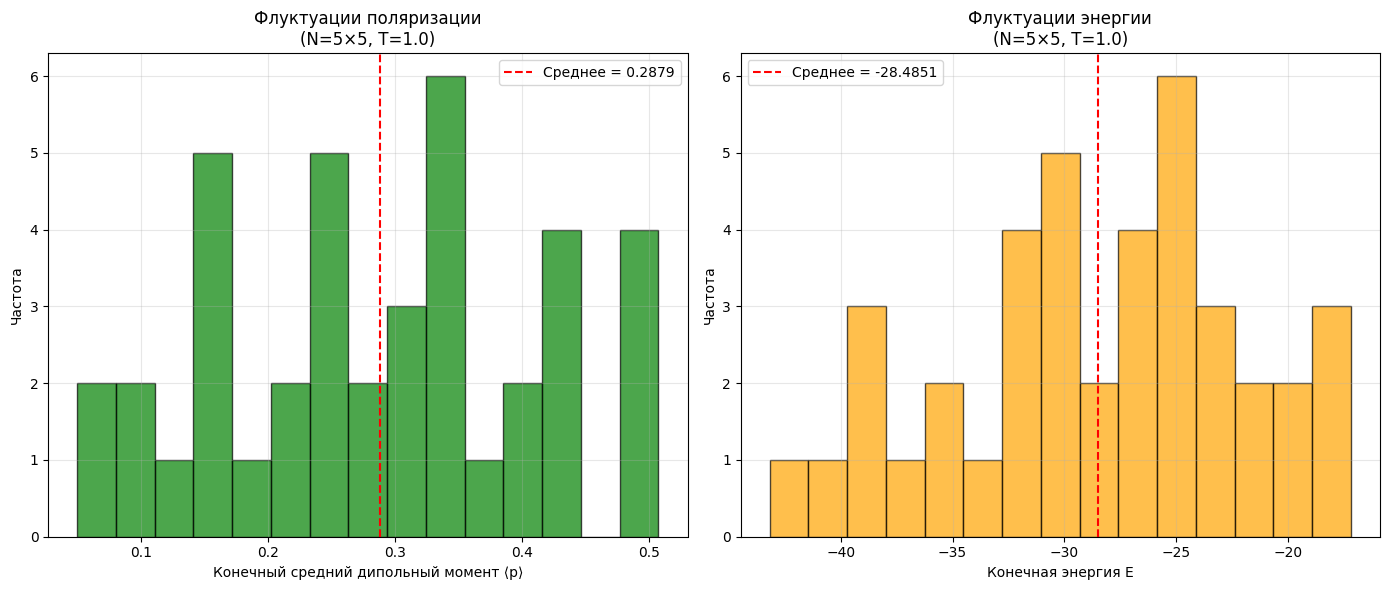

In [ ]:
if __name__ == "__main__":
    N=5
    T=1.0
    n_runs=40
    mc_steps=10000
    burn_in=2000
    sigma=np.pi/3


    run_fluctuations(N, T, n_runs, mc_steps, burn_in, sigma)           # флуктуации при T=1.0

Зависимость от температуры (треугольная решётка)
  Решетка: 5×5 = 25 диполей
  Диапазон температур: [0.04, 0.5, 1.0, 5, 15, 40]
  Прогонов на температуру: 40
Температура T = 0.04
  Подобранная sigma = 0.318 рад (18.2°)
  Прогон 1/40 → ⟨p⟩ = 0.2102, E = -40.6491
  Прогон 2/40 → ⟨p⟩ = 0.9546, E = -42.0696
  Прогон 3/40 → ⟨p⟩ = 0.3724, E = -45.0024
  Прогон 4/40 → ⟨p⟩ = 0.3212, E = -46.5699
  Прогон 5/40 → ⟨p⟩ = 0.2154, E = -49.3771
  Прогон 6/40 → ⟨p⟩ = 0.2402, E = -43.7942
  Прогон 7/40 → ⟨p⟩ = 0.4065, E = -43.3839
  Прогон 8/40 → ⟨p⟩ = 0.2659, E = -38.7099
  Прогон 9/40 → ⟨p⟩ = 0.1872, E = -41.9309
  Прогон 10/40 → ⟨p⟩ = 0.5688, E = -44.6880
  Прогон 11/40 → ⟨p⟩ = 0.4975, E = -44.2620
  Прогон 12/40 → ⟨p⟩ = 0.2978, E = -41.4718
  Прогон 13/40 → ⟨p⟩ = 0.2206, E = -47.0978
  Прогон 14/40 → ⟨p⟩ = 0.2332, E = -46.3367
  Прогон 15/40 → ⟨p⟩ = 0.2789, E = -42.3863
  Прогон 16/40 → ⟨p⟩ = 0.4538, E = -43.5317
  Прогон 17/40 → ⟨p⟩ = 0.2360, E = -39.3213
  Прогон 18/40 → ⟨p⟩ = 0.5589, E = -45.188

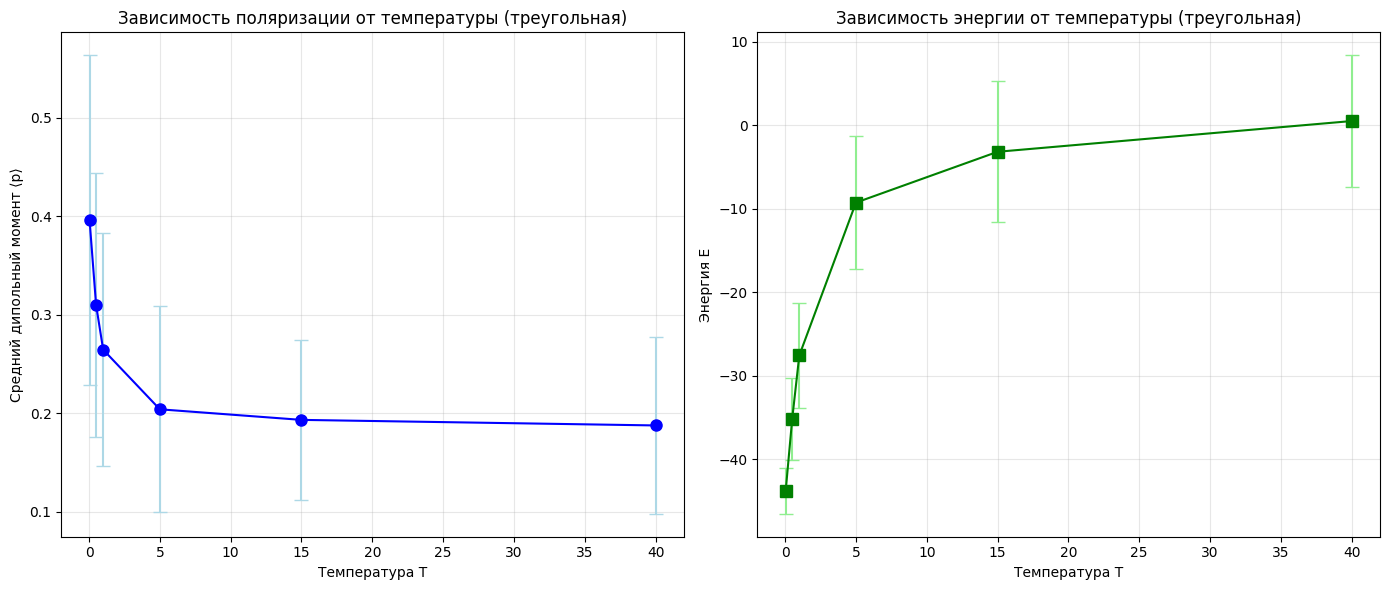

Итог
     T |          ⟨p⟩ |        σ_p |            E |        σ_E
  0.04 |       0.3958 |     0.1676 |     -43.7940 |     2.7591
  0.50 |       0.3097 |     0.1344 |     -35.1742 |     4.9079
  1.00 |       0.2644 |     0.1181 |     -27.5886 |     6.3227
  5.00 |       0.2038 |     0.1047 |      -9.2885 |     7.9585
 15.00 |       0.1931 |     0.0810 |      -3.2028 |     8.4396
 40.00 |       0.1874 |     0.0897 |       0.4783 |     7.8767


In [ ]:
if __name__ == "__main__":
    N=5
    temperatures=[0.04, 0.5, 1.0, 5, 15, 40 ]
    n_runs=40
    mc_steps=1000
    burn_in=200
    sigma=np.pi/8

    run_temperature_dependence(N, temperatures, n_runs, mc_steps, burn_in, sigma) # зависимость от T